# Retail Recommendations via AI-Based Embeddings Vector DB
- Please note that the "womens_clothing_e-commerce_reviews.csv" file used is unavailable as this project was completed via an online course

In [13]:
import pandas as pd
from pathlib import Path

DATA_PATH = Path("..") / "data" / "womens_clothing_synthetic.csv"
reviews = pd.read_csv(DATA_PATH)

reviews.head()

,Review ID,Clothing ID,Age,Rating,Recommended IND,Positive Feedback Count,Division Name,Department Name,Class Name,Title,Review Text
0,0,1094,53,3,0,0,General,Tops,Knits,NaN,And runs dress the size likely the plaid think...
1,1,252,54,1,0,0,General,Dresses,Dresses,Cute Color Small,Hole just in good work sized has the can this ...
2,2,886,32,3,1,0,General,Tops,Blouses,Better The Fall Fall,Has style if bought to quality ok sleeve and m...
3,3,1008,26,5,1,1,General,Bottoms,Skirts,Buttondown Ruffled Of Beautiful The,This size find short and expecting too on is g...
4,4,1094,39,5,1,0,General,Tops,Blouses,Shorter Recommend Thin Big,Look comfortable and twill still there buttons...


In [14]:
# Cleaning the data

reviews = reviews[reviews['Review Text'].notna()]                     # remove NaN
reviews = reviews[reviews['Review Text'].astype(str).str.strip() != '']  # remove empty strings

In [15]:
# Basic Embeddings Setup & OpenAI Call

import os
from dotenv import load_dotenv

load_dotenv()
from openai import OpenAI
# Define the model to use
model = "text-embedding-3-small"
# Define the client
api_key = os.getenv("OPENAI_API_KEY")
client = OpenAI()

# Create Embeddings Endpoint
review_text = reviews['Review Text'].tolist()

response = client.embeddings.create(
    model=model,
    input= review_text
)

In [18]:
# Dimensionality Reduction (t-SNE) - for the sole purpose of Visualization

from sklearn.manifold import TSNE
import numpy as np

embeddings = [item.embedding for item in response.data]
embeddings_array = np.array(embeddings)

tsne = TSNE(n_components=2, perplexity=5, random_state=42)
embeddings_2d = tsne.fit_transform(embeddings_array)


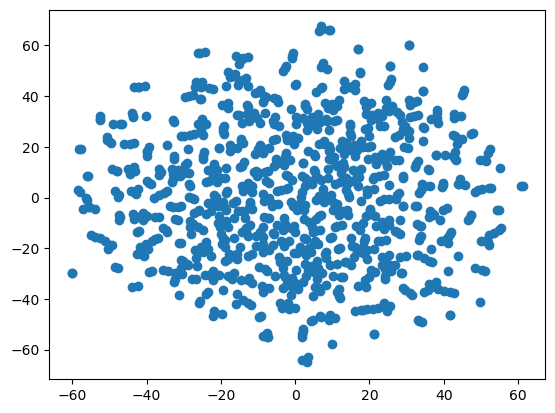

In [19]:
# Visualizing the embeddings

import matplotlib.pyplot as plt

plt.scatter(embeddings_2d[:,0], embeddings_2d[:,1])
plt.show()

In [20]:
# Creating a "Create Embeddings" Function I can reuse:

def create_embeddings(texts):
    response = client.embeddings.create(
        model = model,
        input = texts
    )
    response_dict = response.model_dump()

    return [data['embedding'] for data in response_dict['data']]

In [21]:
# Creating Topics for Classification
# First create a dictionary of topics - product quality, comfort, style, price, sustainability, customer service
topics = [
     {'label': 'quality'},
     {'label': 'comfort'},
     {'label': 'style'},
     {'label': 'price'},
     {'label': 'sustainability'},
     {'label': 'customer service'},
]
class_descriptions = [topic['label'] for topic in topics]
class_embeddings = create_embeddings(class_descriptions)

In [22]:
# Computing Cosine Distances for all embeddings

from scipy.spatial import distance

# Single Comparison Function
def find_closest(query_vector, embeddings):
    distances = []
    for index, embedding in enumerate(embeddings):
        dist = distance.cosine(query_vector, embedding)
        distances.append({"distance": dist, "index": index})
    return min(distances, key = lambda x: x['distance'])

# Looped over all my embeddings
results = []
for i, query_vec in enumerate(embeddings):  
    closest = find_closest(query_vec, class_embeddings)
    label = topics[closest["index"]]["label"]       
    results.append(label)

In [24]:
# Shelling out Three Reviews for Each Category

def find_top_n_reviews(topic_vector, review_vectors, n=3):
    """
    topic_vector: embedding of the topic
    review_vectors: list of embeddings (one per review)
    n: how many closest reviews to return
    """
    distances = []
    for i, review_vec in enumerate(review_vectors):
        dist = distance.cosine(topic_vector, review_vec)
        distances.append({"index": i, "distance": dist})
    
    distances = sorted(distances, key=lambda x: x["distance"])
    return distances[:n]  

for i, topic in enumerate(topics):
    topic_label = topic["label"]
    topic_vec = class_embeddings[i]   
    top_reviews = find_top_n_reviews(topic_vec, embeddings_array, n=3)
    
    print(f"\n Top 3 reviews for topic: {topic_label.upper()}")
    for rank, item in enumerate(top_reviews, start=1):
        review_text = reviews.iloc[item["index"]]["Review Text"]
        print(f"{rank}. {review_text.strip()}")


 Top 3 reviews for topic: QUALITY
1. Is person small beautiful fine fullness many if has but quality picture.
2. Imperfections the to ways look the and the size coat simple short am looking well quality grey the overall love skinny is top too it flare the easy and to needed the at rip priority kind in the just!
3. The to quality piece runs trying denim my with lace and chest is usually post reviews bottom attitude there straight pretty read doesn not with softer hangs form my and with sweater to seems the thing they style style fabric won was thought job to very they because thought want fabric wrinkled more first and be honestly and good that it away this the are me top not summer below to the the you especially honestly product especially would just neck made am in so.

 Top 3 reviews for topic: COMFORT
1. As cozy up buttons as and and the for need of retailer and to wanted flirtiness lining being and but droop my supportive and for don but it overall wearing to with it because weig

In [25]:
# Reusing the Above Function to Shell out Most Similar Reviews for a Given REVIEW

most_similar = find_top_n_reviews(embeddings[0], embeddings, n=3)

most_similar_reviews = [
    reviews.iloc[item["index"]]["Review Text"].strip()
    for item in most_similar
]